In [2]:
import torch
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from hydra import compose, initialize
from scipy.stats import norm

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1]))

from maps_to_cosmology.flowmatching import FlowMatching
from maps_to_cosmology.datamodule import ConvergenceMapsModule

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Initialize the config:

In [3]:
with initialize(config_path="../configs", version_base=None):
    cfg = compose("train_flowmatching_lsst_y10")

Instantiate the encoder using the checkpoint from a previous training run:

In [4]:
ckpt = "/data/scratch/blissWL_checkpoints/FlowMatching_Standardized.ckpt"
model = FlowMatching.load_from_checkpoint(ckpt, weights_only=False)
model.eval()
model.to(device)

FlowMatching(
  (map_encoder): ResNet(
    (stem): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
    )
    (layer1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (layer2): ResidualBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

Instantiate the test dataloader:

In [5]:
# this cell takes approximately 3 minutes
datamodule = ConvergenceMapsModule(
    data_dir=cfg.paths.data_dir,
    batch_size=cfg.convergence_maps.batch_size,
    num_workers=cfg.convergence_maps.num_workers,
    val_split=cfg.convergence_maps.val_split,
    test_split=cfg.convergence_maps.test_split,
    seed=cfg.seed,
    standardize_params=cfg.convergence_maps.standardize_params,
)
datamodule.setup()
test_loader = datamodule.test_dataloader()

Loading combined_batches.pt from /data/scratch/convergence_maps/lsst_y10_lognormal_with_noise


Loaded 99999 samples
Maps shape: torch.Size([99999, 256, 256, 5])
Params shape: torch.Size([99999, 6])
Train samples: 80001
Val samples: 9999
Test samples: 9999
Standardized cosmological parameters using TRAIN stats.
Train mean: tensor([ 0.3020,  0.0492,  0.8313,  0.6725,  0.9642, -1.1142])
Train std:  tensor([0.1704, 0.0060, 0.1402, 0.0629, 0.0801, 0.4615])


Load in the convergence maps from the test set and evaluate the model on them. Also load the correspoding cosmological parameters from the test set:

In [6]:
posterior_means = []
posterior_stdevs = []
true_params = []

with torch.no_grad():
    for maps, params in test_loader:
        maps = maps.to(device)
        samples = torch.stack([model.predict(maps, use_mode=False) for _ in range(100)], dim=0)
        posterior_mean = samples.mean(dim=0)
        posterior_std = samples.std(dim=0)
        posterior_means.append(posterior_mean.cpu())
        posterior_stdevs.append(posterior_std.cpu())
        true_params.append(params)

posterior_means = torch.cat(posterior_means, dim=0)
posterior_stdevs = torch.cat(posterior_stdevs, dim=0)
true_params = torch.cat(true_params, dim=0)

For each of the six cosmological parameters, create a scatterplot of the true parameter value versus the posterior mean. Arrange the six scatterplots in a 2x3 grid.

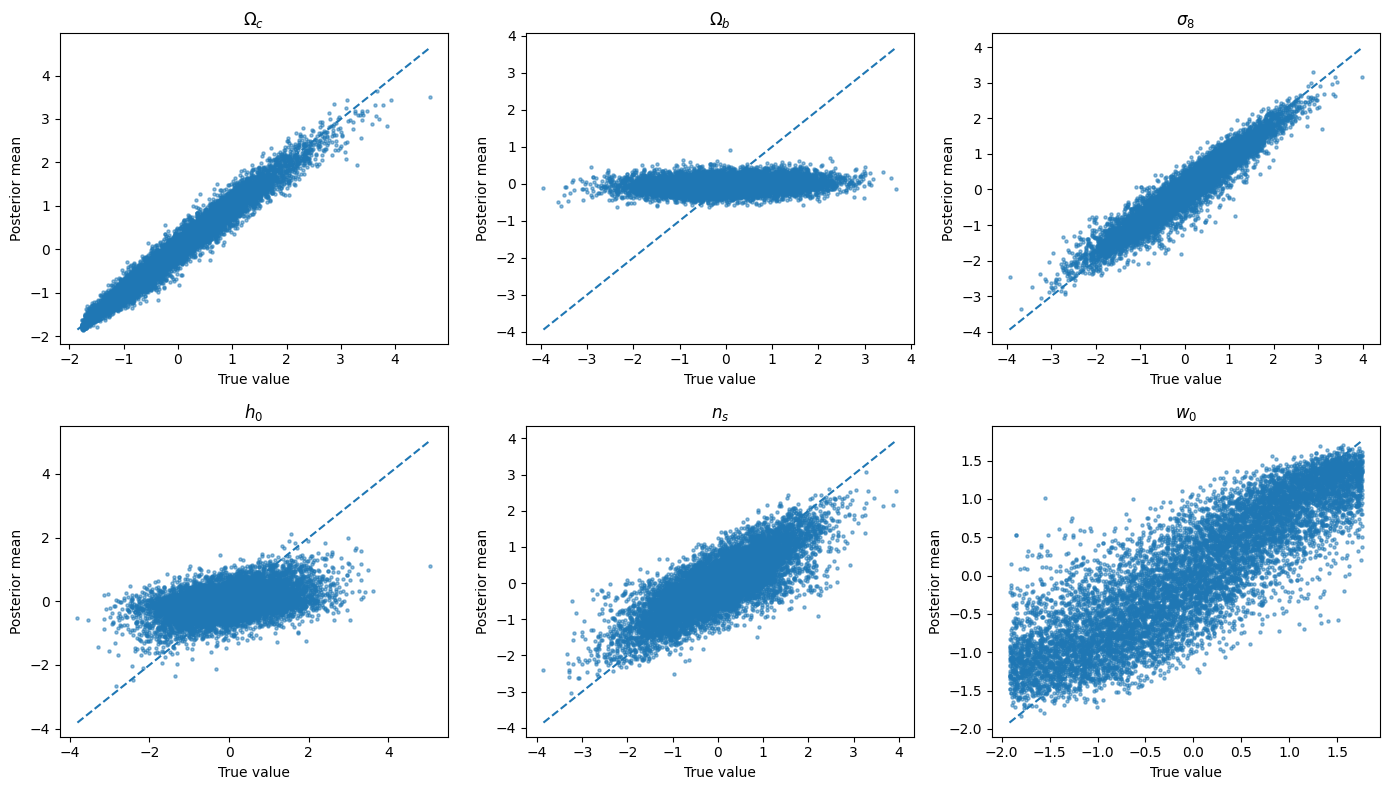

In [7]:
param_names = [
    r"$\Omega_c$", r"$\Omega_b$", r"$\sigma_8$",
    r"$h_0$", r"$n_s$", r"$w_0$"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]

    x = true_params[:, i].numpy()
    y = posterior_means[:, i].numpy()

    ax.scatter(x, y, s=5, alpha=0.5)
    minv = min(x.min(), y.min())
    maxv = max(x.max(), y.max())
    ax.plot([minv, maxv], [minv, maxv], linestyle="--")

    ax.set_xlabel("True value")
    ax.set_ylabel("Posterior mean")
    ax.set_title(param_names[i])

plt.tight_layout()
plt.show()

We load in the convergence map used as a reference map in this paper (https://arxiv.org/pdf/2409.17975):

In [8]:
reference_map = np.load("reference_map.npy")
reference_params = [0.2664, 0.0492, 0.831, 0.6727, 0.9645, -1.0]

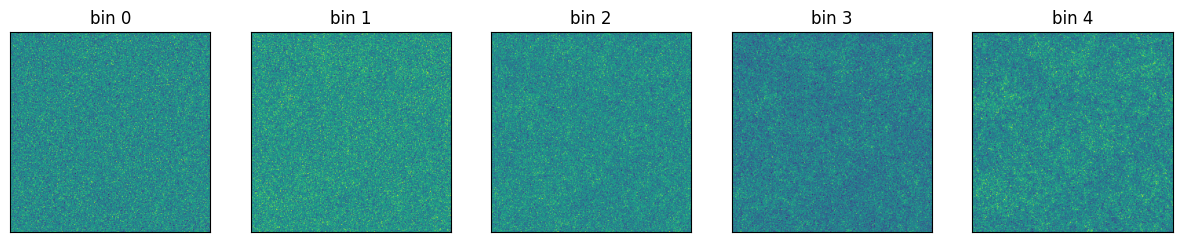

In [9]:
fig, ax = plt.subplots(1, 5, figsize = (15, 3))

for b in range(5):
    _ = ax[b].imshow(reference_map[...,b])
    _ = ax[b].set_title(f"bin {b}")
    _ = ax[b].set_xticks([])
    _ = ax[b].set_yticks([])

We plug this reference map into our trained model and plot the contours of the resulting posterior distributions:

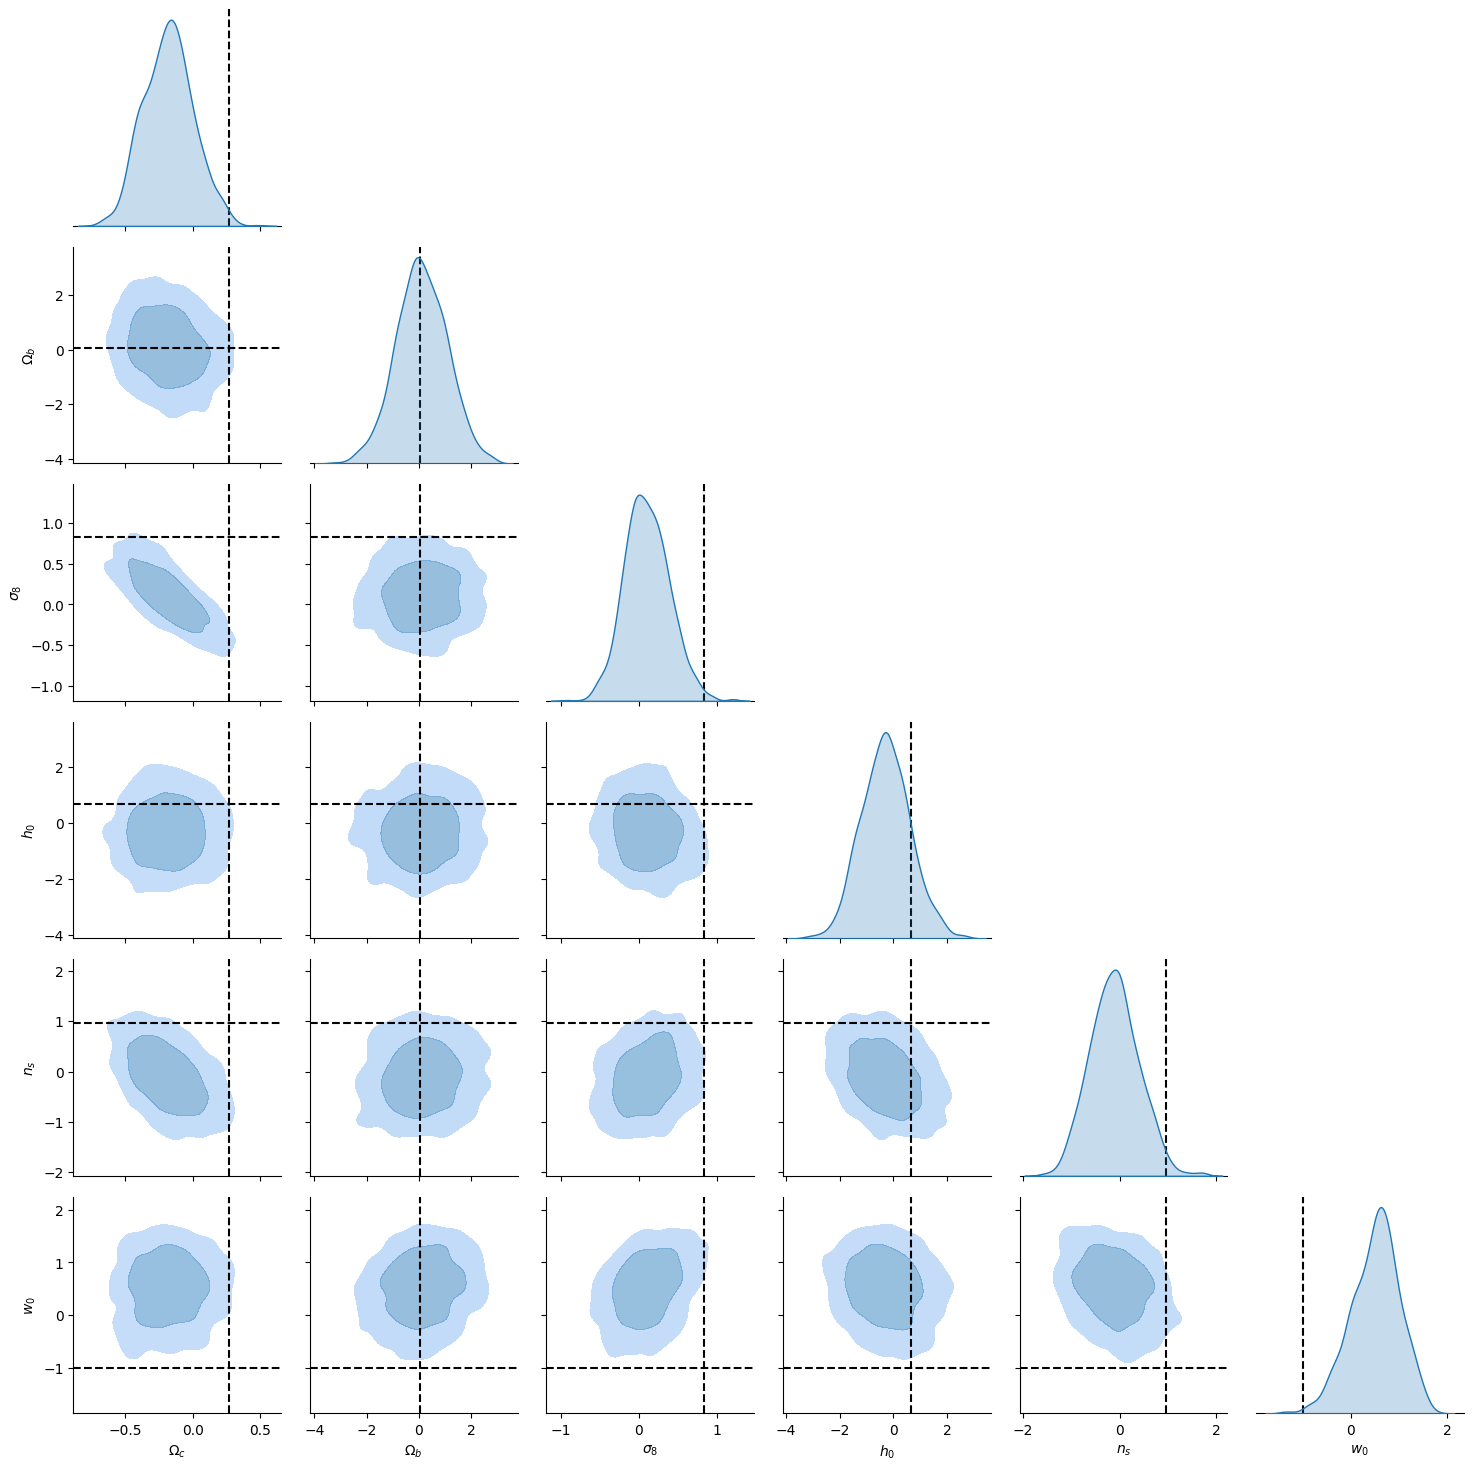

In [10]:
num_samples = 1000

with torch.no_grad():
    reference_map_tensor = (
        torch.tensor(reference_map)
        .permute(2, 0, 1)          # [H,W,C] -> [C,H,W]
        .unsqueeze(0)              # -> [1,C,H,W]
        .to(device)
        .float()
    )
    samples = []
    for _ in range(num_samples):
        samp = model.predict(reference_map_tensor, use_mode=False)
        samples.append(samp.squeeze(0).cpu())
    samples = torch.stack(samples, dim=0)

posterior_mean = samples.mean(dim=0)
posterior_stdev = samples.std(dim=0)
df = pd.DataFrame(samples.numpy(), columns=param_names)

g = sns.PairGrid(df, corner=True, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(sns.kdeplot, levels=[0.05, 0.32, 1.0], fill=True, alpha=0.5)

for i in range(6):
    g.axes[i, i].axvline(reference_params[i], color="black", linestyle="--")
    for j in range(i):
        g.axes[i, j].axvline(reference_params[j], color="black", linestyle="--")
        g.axes[i, j].axhline(reference_params[i], color="black", linestyle="--")

We plug a map from test set into our trained model and plot the contours of the resulting posterior distributions:

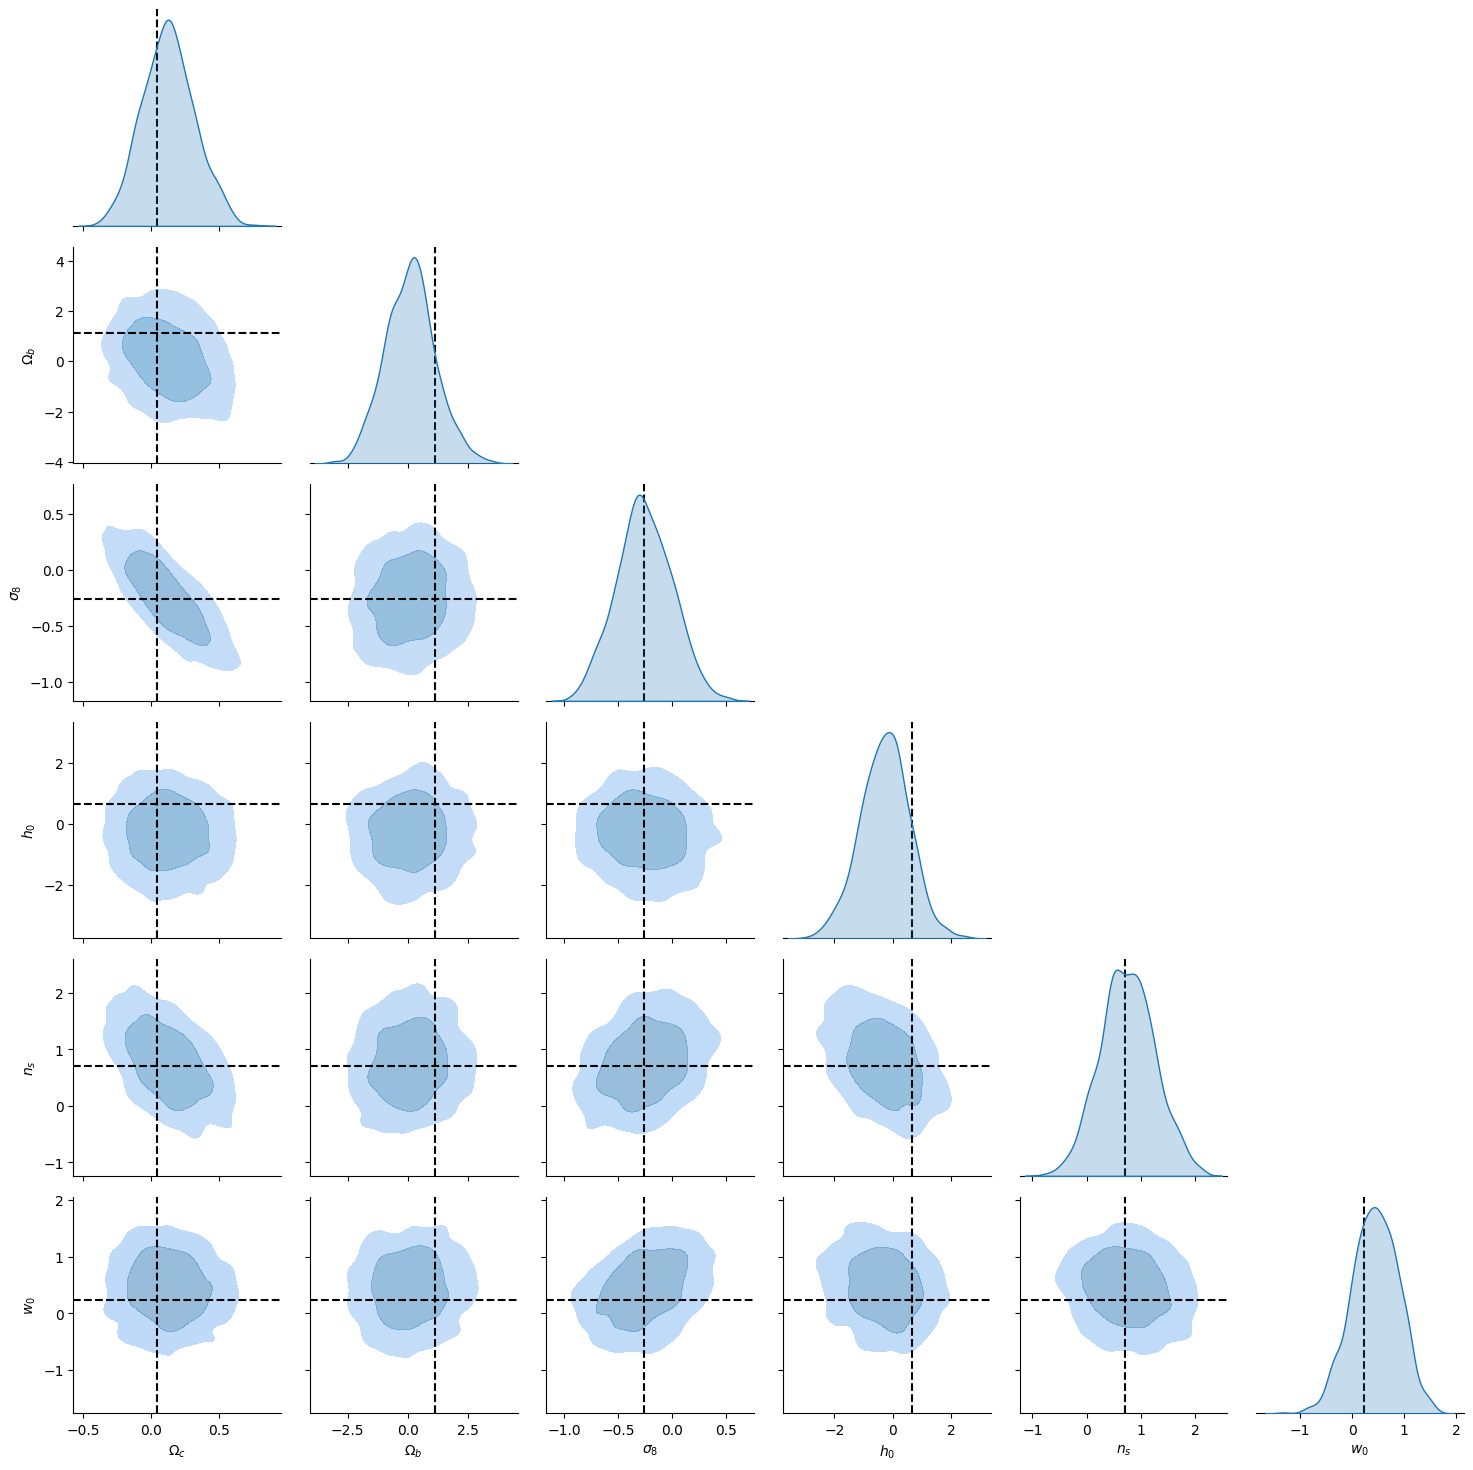

In [11]:
maps, params = next(iter(test_loader))

sample_idx = 0

selected_map = maps[sample_idx]
selected_params = params[sample_idx]

num_samples = 1000

with torch.no_grad():
    selected_map_tensor = selected_map.unsqueeze(0).to(device).float()

    samples = []
    for _ in range(num_samples):
        samp = model.predict(selected_map_tensor, use_mode=False)
        samples.append(samp.squeeze(0).cpu())
    samples = torch.stack(samples, dim=0)

posterior_mean = samples.mean(dim=0)
posterior_stdev = samples.std(dim=0)
df = pd.DataFrame(samples.numpy(), columns=param_names)

g = sns.PairGrid(df, corner=True, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(sns.kdeplot, levels=[0.05, 0.32, 1.0], fill=True, alpha=0.5)

true_vals = selected_params.cpu().numpy()

for i in range(6):
    g.axes[i, i].axvline(true_vals[i], color="black", linestyle="--")
    for j in range(i):
        g.axes[i, j].axvline(true_vals[j], color="black", linestyle="--")
        g.axes[i, j].axhline(true_vals[i], color="black", linestyle="--")

Plot credible intervals:

Credible Interval Level: 90%
$\Omega_c$: Coverage = 0.950
$\Omega_b$: Coverage = 0.904
$\sigma_8$: Coverage = 0.930
$h_0$: Coverage = 0.884
$n_s$: Coverage = 0.886
$w_0$: Coverage = 0.874


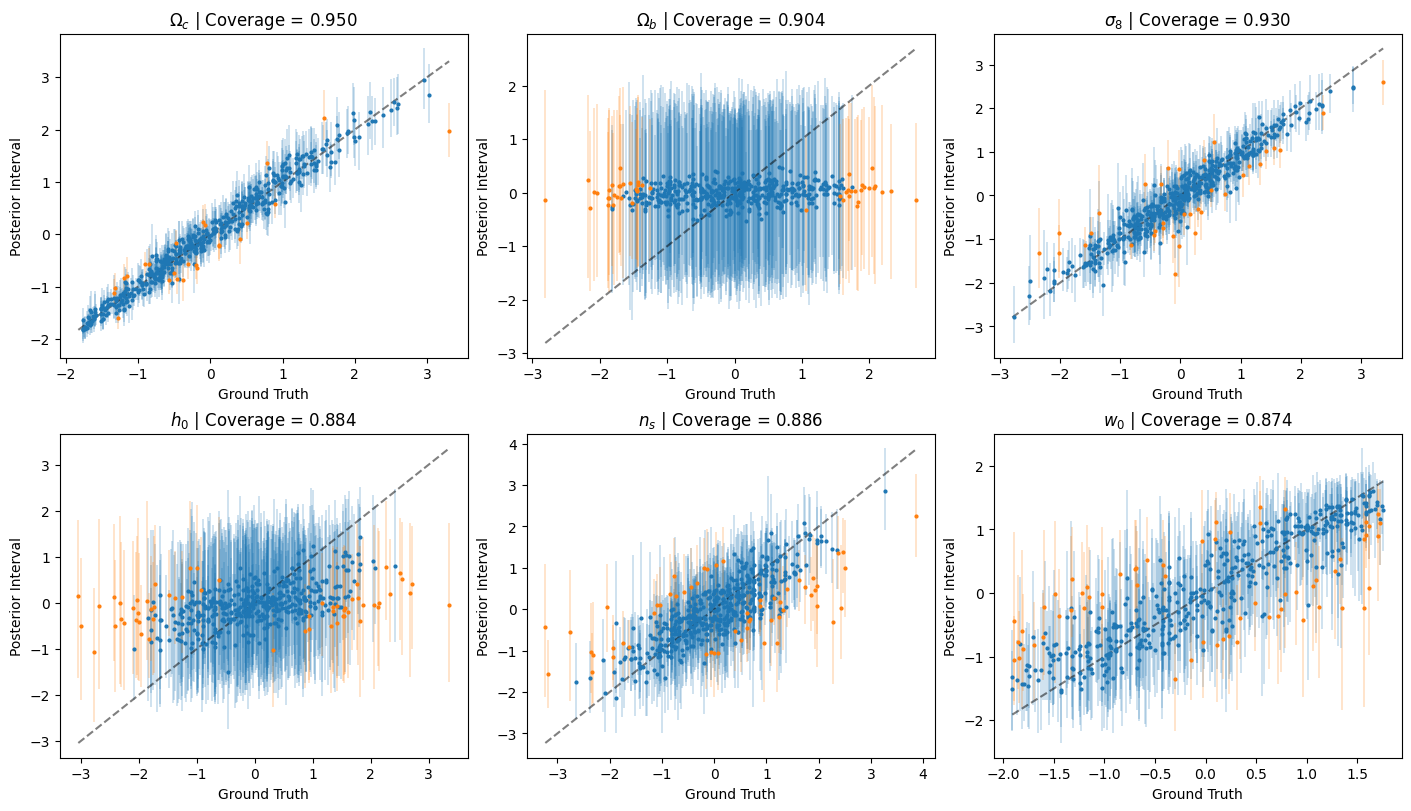

In [12]:
ci_level = 0.90
alpha = 1 - ci_level
lower_q = alpha / 2
upper_q = 1 - alpha / 2

n_plot = 500
rng = np.random.default_rng(42)
all_samples = []
all_true = []

num_posterior_samples = 100

model.eval()
with torch.no_grad():
    for maps, params in test_loader:
        maps = maps.to(device)
        params = params.to(device)

        batch_samples = []
        for _ in range(num_posterior_samples):
            samp = model.predict(maps, use_mode=False)
            batch_samples.append(samp)
        batch_samples = torch.stack(batch_samples, dim=0)

        all_samples.append(batch_samples.cpu())
        all_true.append(params.cpu())

all_samples = torch.cat(all_samples, dim=1)
all_true = torch.cat(all_true, dim=0)

mu = all_samples.mean(dim=0).numpy()
lower = torch.quantile(all_samples, lower_q, dim=0).numpy()
upper = torch.quantile(all_samples, upper_q, dim=0).numpy()
true = all_true.numpy()

N = true.shape[0]
idx = rng.choice(N, size=min(n_plot, N), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

print(f"Credible Interval Level: {int(ci_level * 100)}%")
coverages = []

for j, name in enumerate(param_names):
    x = true[idx, j]
    y = mu[idx, j]
    lo = lower[idx, j]
    hi = upper[idx, j]

    covered = (x >= lo) & (x <= hi)
    cov = covered.mean()
    coverages.append(cov)
    print(f"{name}: Coverage = {cov:.3f}")

    ax = axes[j]
    ax.errorbar(
        x[covered],
        y[covered],
        yerr=np.vstack([y[covered] - lo[covered], hi[covered] - y[covered]]),
        fmt="o",
        markersize=2,
        alpha=1,
        linewidth=0.3,
        capsize=0,
    )
    ax.errorbar(
        x[~covered],
        y[~covered],
        yerr=np.vstack([y[~covered] - lo[~covered], hi[~covered] - y[~covered]]),
        fmt="o",
        markersize=2,
        alpha=1,
        linewidth=0.3,
        capsize=0,
    )
    dmin = min(x.min(), y.min())
    dmax = max(x.max(), y.max())
    ax.plot([dmin, dmax], [dmin, dmax], "k--", alpha=0.5)
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Posterior Interval")
    ax.set_title(f"{name} | Coverage = {cov:.3f}")
plt.show()

Empirical Coverage vs Nominal Coverage

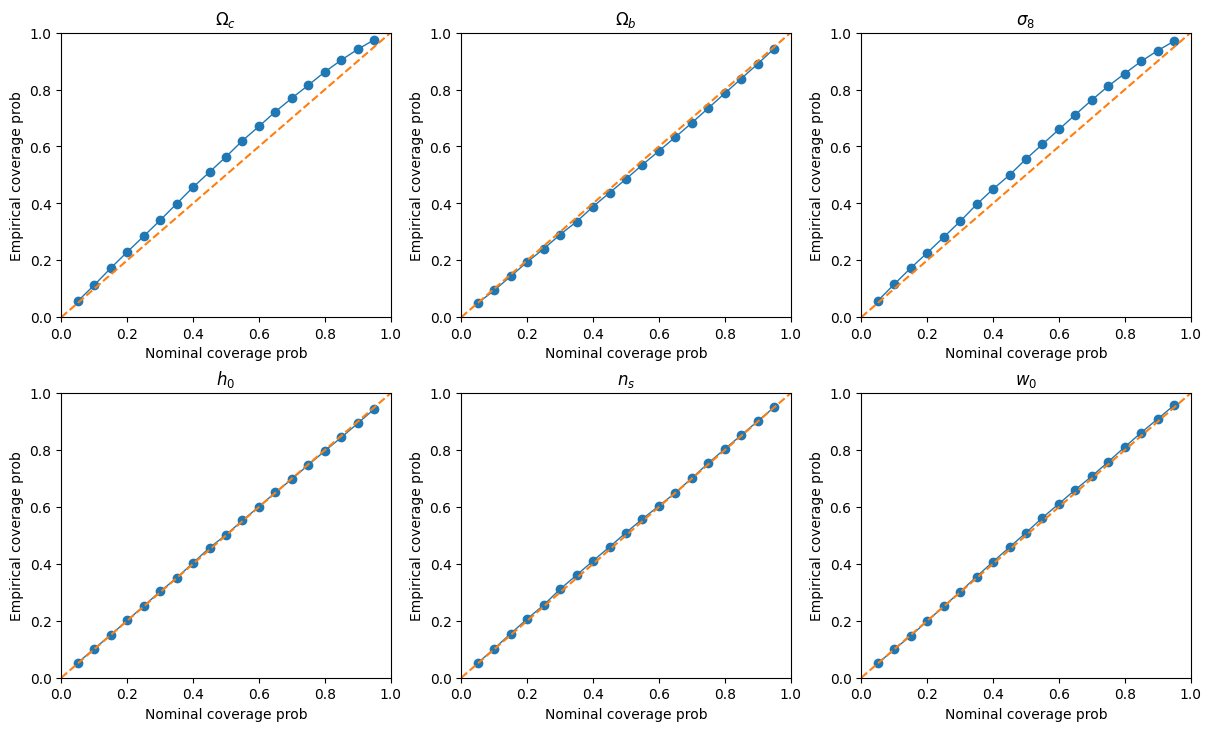

ECE per parameter:
  $\Omega_c$: 0.0477
  $\Omega_b$: 0.0110
  $\sigma_8$: 0.0427
  $h_0$: 0.0028
  $n_s$: 0.0053
  $w_0$: 0.0069


In [13]:
all_samples = []
all_true = []

model.eval()

levels = np.linspace(0.05, 0.95, 19)
K = len(levels)

with torch.no_grad():
    for maps, params in test_loader:
        maps = maps.to(device)
        params = params.to(device)

        batch_samples = []
        for _ in range(100):
            samp = model.predict(maps, use_mode=False)
            batch_samples.append(samp)
        batch_samples = torch.stack(batch_samples, dim=0)

        all_samples.append(batch_samples.cpu())
        all_true.append(params.cpu())

all_samples = torch.cat(all_samples, dim=1)
all_true = torch.cat(all_true, dim=0)

mu = all_samples.mean(dim=0).numpy()
sigma = all_samples.std(dim=0).numpy()
y_true = all_true.numpy()

N, d = y_true.shape
assert d == len(param_names)

emp = np.zeros((K, d), dtype=float)

for k, c in enumerate(levels):
    z = norm.ppf((1.0 + c) / 2.0)
    lo = mu - z * sigma
    hi = mu + z * sigma
    inside = (y_true >= lo) & (y_true <= hi)
    emp[k] = inside.mean(axis=0)

ncols = 3
nrows = int(np.ceil(d / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.6*nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for j in range(d):
    ax = axes[j]
    ax.plot(levels, emp[:, j], marker="o", linewidth=1)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(param_names[j])
    ax.set_xlabel("Nominal coverage prob")
    ax.set_ylabel("Empirical coverage prob")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(d, len(axes)):
    axes[j].axis("off")

plt.show()
ece = np.mean(np.abs(emp - levels[:, None]), axis=0)
print("ECE per parameter:")
for name, val in zip(param_names, ece):
    print(f"  {name}: {val:.4f}")